# Exploração dos dados Silver da NASA POWER

Este notebook verifica a qualidade e explora as séries meteorológicas diárias de Sorriso–MT. A fonte é o Parquet da camada Silver, particionado por ano. Todos os caminhos são relativos à raiz do repositório.

## Preparação e carregamento

O conjunto particionado é lido como um único dataset. A coluna `year`, derivada dos diretórios de partição, é mantida para facilitar filtros futuros. A ordenação por data garante que acumulados e sequências sejam calculados cronologicamente.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.dataset as ds

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

PROJECT_ROOT = Path(".") if Path("data").exists() else Path("..")
SILVER_PATH = PROJECT_ROOT / "data/silver/nasa_power/daily/municipality_code=5107925"
if not SILVER_PATH.exists():
    raise FileNotFoundError(
        f"Dataset Silver não encontrado em {SILVER_PATH}. "
        "Execute o notebook a partir da raiz do repositório e gere a camada Silver primeiro."
    )

dataset = ds.dataset(SILVER_PATH, format="parquet", partitioning="hive")
table = dataset.to_table()
weather = table.to_pandas().sort_values("date").reset_index(drop=True)
weather["date"] = pd.to_datetime(weather["date"])

print(f"Linhas: {len(weather):,}")
print(f"Período: {weather['date'].min().date()} a {weather['date'].max().date()}")
weather.head()

Linhas: 243
Período: 2023-09-01 a 2024-04-30


,date,latitude,longitude,temperature_mean_c,temperature_max_c,temperature_min_c,relative_humidity_pct,wind_speed_ms,solar_radiation_mj_m2_day,precipitation_mm_day,year
0,2023-09-01,-12.692,-55.776,28.85,36.38,22.74,64.68,0.13,20.01,3.81,2023
1,2023-09-02,-12.692,-55.776,28.56,37.03,21.73,63.52,0.03,19.22,1.49,2023
2,2023-09-03,-12.692,-55.776,29.48,36.01,23.68,54.87,0.08,18.93,1.50,2023
3,2023-09-04,-12.692,-55.776,29.08,37.87,21.54,54.90,0.12,24.07,0.04,2023
4,2023-09-05,-12.692,-55.776,30.82,39.18,23.14,43.23,0.31,20.83,0.02,2023


## Schema e unidades

O schema abaixo apresenta os tipos físicos do Parquet. As unidades são recuperadas dos metadados de cada campo, preservando o contrato definido na transformação Silver. Datas não possuem unidade, e coordenadas geográficas são expressas em graus decimais.

In [2]:
schema_rows = []
for field in table.schema:
    metadata = field.metadata or {}
    schema_rows.append(
        {
            "column": field.name,
            "type": str(field.type),
            "unit": metadata.get(b"unit", b"").decode() or "—",
            "description": metadata.get(b"description", b"").decode() or "—",
        }
    )

schema_summary = pd.DataFrame(schema_rows)
schema_summary

,column,type,unit,description
0,date,date32[day],date,Observation date in UTC
1,latitude,double,degrees_north,NASA POWER point latitude
2,longitude,double,degrees_east,NASA POWER point longitude
3,temperature_mean_c,double,C,Mean air temperature at 2 meters
4,temperature_max_c,double,C,Maximum air temperature at 2 meters
5,temperature_min_c,double,C,Minimum air temperature at 2 meters
6,relative_humidity_pct,double,%,Relative humidity at 2 meters
7,wind_speed_ms,double,m/s,Wind speed at 2 meters
8,solar_radiation_mj_m2_day,double,MJ/m^2/day,All-sky surface shortwave downward irradiance
9,precipitation_mm_day,double,mm/day,Corrected precipitation


## Estatísticas descritivas

As estatísticas resumem cobertura, média, dispersão e extremos de cada variável numérica. Valores mínimos e máximos ajudam a localizar eventos meteorológicos extremos; a contagem permite confirmar se cada variável cobre todas as datas.

In [3]:
weather.describe(include="all").T

,count,mean,min,25%,50%,75%,max,std
date,243,2023-12-31 00:00:00,2023-09-01 00:00:00,2023-10-31 12:00:00,2023-12-31 00:00:00,2024-02-29 12:00:00,2024-04-30 00:00:00,NaN
latitude,243.0,-12.692,-12.692,-12.692,-12.692,-12.692,-12.692,0.0
longitude,243.0,-55.776,-55.776,-55.776,-55.776,-55.776,-55.776,0.0
temperature_mean_c,243.0,27.854568,23.96,25.62,26.96,30.23,34.08,2.622774
temperature_max_c,243.0,32.988436,25.55,29.155,31.02,37.355,41.56,4.54399
temperature_min_c,243.0,23.373539,20.92,22.66,23.24,23.955,27.62,1.134388
relative_humidity_pct,243.0,73.654856,28.01,58.365,84.14,90.545,97.54,19.304728
wind_speed_ms,243.0,0.092428,0.02,0.04,0.06,0.13,0.31,0.06923
solar_radiation_mj_m2_day,243.0,20.353621,7.58,17.855,20.55,23.23,28.09,4.014751
precipitation_mm_day,243.0,5.442428,0.0,0.38,2.42,6.875,64.73,8.44737


## Nulos e datas duplicadas

Nulos indicam dias sem observação para uma variável e precisam ser considerados antes de agregações. Datas duplicadas violariam a granularidade esperada de uma linha por dia. A célula reporta ambos explicitamente e mostra as linhas duplicadas, caso existam.

In [4]:
null_summary = (
    weather.isna()
    .sum()
    .rename("null_count")
    .to_frame()
    .assign(null_pct=lambda frame: frame["null_count"] / len(weather) * 100)
)
duplicate_mask = weather.duplicated(subset=["date"], keep=False)
duplicate_dates = weather.loc[duplicate_mask].sort_values("date")

print(f"Total de valores nulos: {int(null_summary['null_count'].sum())}")
print(f"Linhas associadas a datas duplicadas: {len(duplicate_dates)}")
display(null_summary)
duplicate_dates

Total de valores nulos: 0
Linhas associadas a datas duplicadas: 0


,null_count,null_pct
date,0,0.0
latitude,0,0.0
longitude,0,0.0
temperature_mean_c,0,0.0
temperature_max_c,0,0.0
temperature_min_c,0,0.0
relative_humidity_pct,0,0.0
wind_speed_ms,0,0.0
solar_radiation_mj_m2_day,0,0.0
precipitation_mm_day,0,0.0


,date,latitude,longitude,temperature_mean_c,temperature_max_c,temperature_min_c,relative_humidity_pct,wind_speed_ms,solar_radiation_mj_m2_day,precipitation_mm_day,year


## Chuva diária e acumulada

As barras mostram a precipitação observada em cada dia, em milímetros por dia. A curva acumulada é a soma cronológica da chuva válida desde o início do estudo; períodos em que a curva fica quase horizontal correspondem a pouca ou nenhuma precipitação. Valores ausentes não são convertidos em chuva zero.

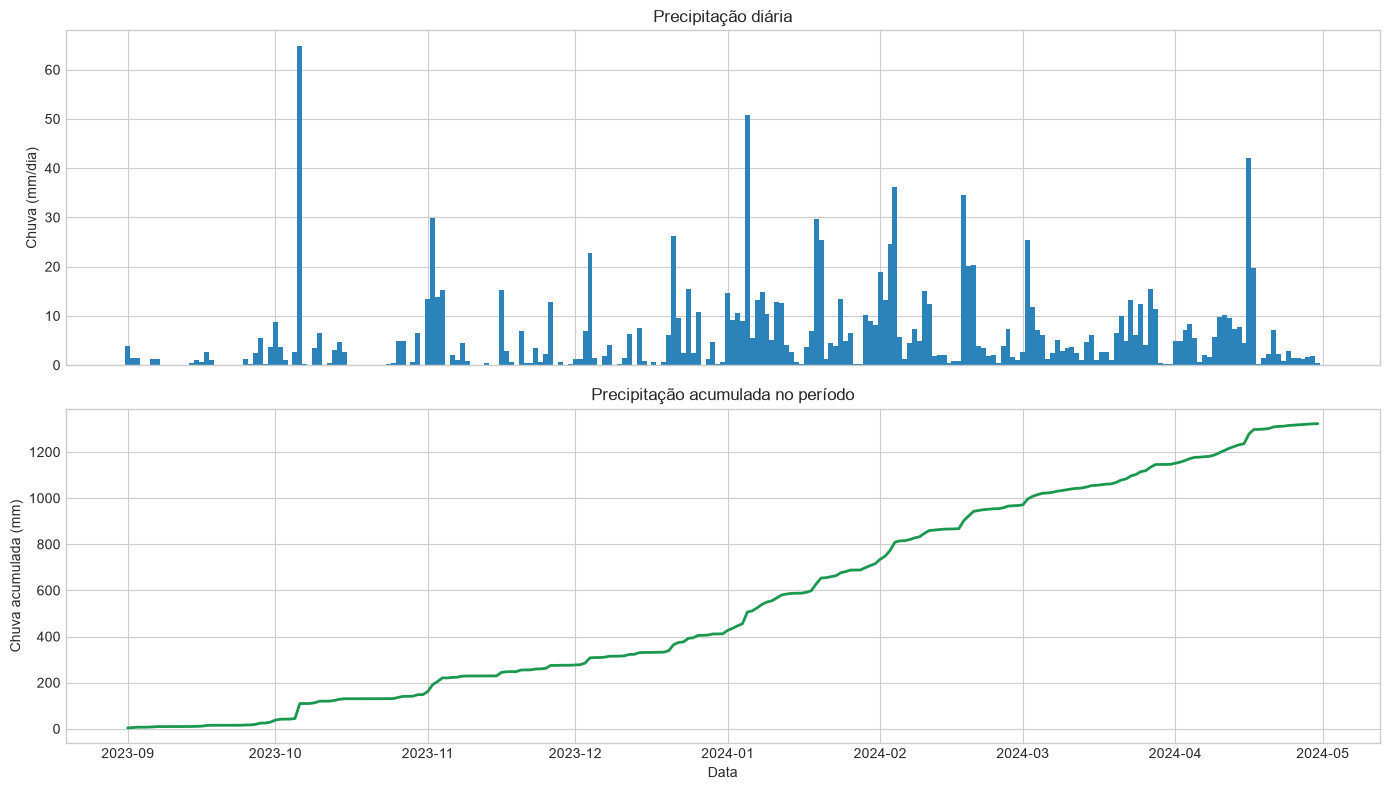

In [5]:
weather["precipitation_accumulated_mm"] = weather["precipitation_mm_day"].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].bar(weather["date"], weather["precipitation_mm_day"], width=1.0, color="#2b83ba")
axes[0].set(title="Precipitação diária", ylabel="Chuva (mm/dia)")
axes[1].plot(weather["date"], weather["precipitation_accumulated_mm"], color="#1a9850", linewidth=2)
axes[1].set(title="Precipitação acumulada no período", xlabel="Data", ylabel="Chuva acumulada (mm)")
fig.tight_layout()
plt.show()

## Temperaturas mínima, média e máxima

As três séries, em graus Celsius, representam a amplitude térmica diária. A faixa sombreada evidencia o intervalo entre mínima e máxima, enquanto a linha central acompanha a temperatura média. Cruzamentos ou valores fora da faixa esperada indicariam possível problema de qualidade.

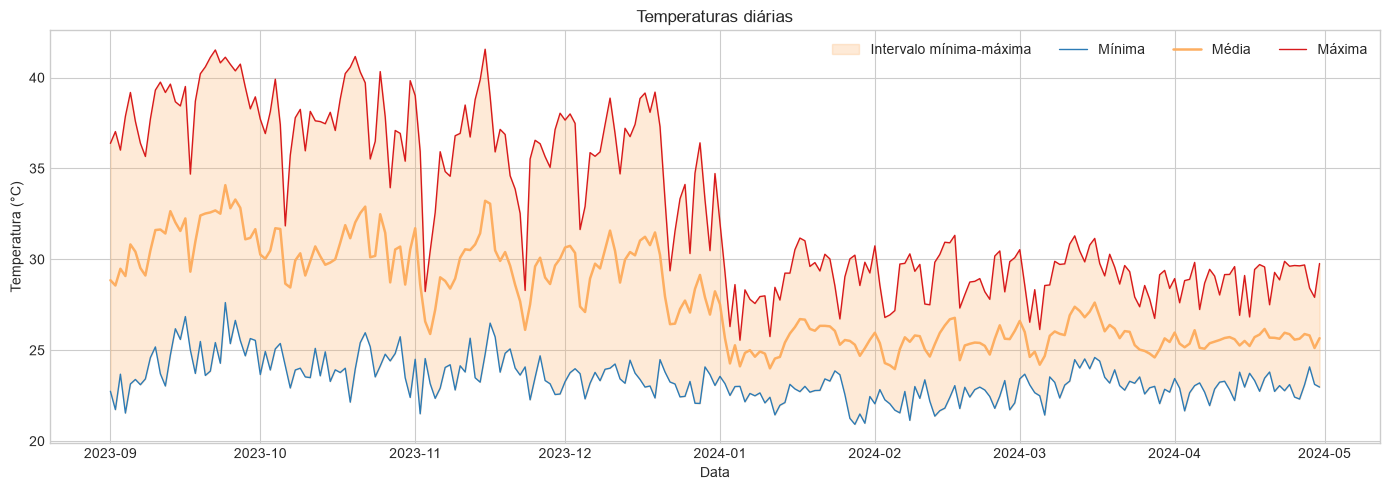

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(
    weather["date"],
    weather["temperature_min_c"],
    weather["temperature_max_c"],
    color="#fdae61",
    alpha=0.25,
    label="Intervalo mínima-máxima",
)
ax.plot(
    weather["date"],
    weather["temperature_min_c"],
    label="Mínima",
    color="#2c7bb6",
    linewidth=1,
)
ax.plot(
    weather["date"],
    weather["temperature_mean_c"],
    label="Média",
    color="#fdae61",
    linewidth=1.8,
)
ax.plot(
    weather["date"],
    weather["temperature_max_c"],
    label="Máxima",
    color="#d7191c",
    linewidth=1,
)
ax.set(title="Temperaturas diárias", xlabel="Data", ylabel="Temperatura (°C)")
ax.legend(ncol=4)
fig.tight_layout()
plt.show()

## Dias consecutivos sem chuva

Neste notebook, um **dia sem chuva** é definido como precipitação inferior a 1 mm/dia. A sequência reinicia quando ocorre chuva igual ou superior a esse limite. Observações nulas não são classificadas como dias secos e também interrompem a sequência, evitando inferir ausência de chuva quando não há medição.

Maior sequência sem chuva: 10 dias
Período da maior sequência: 2023-10-16 a 2023-10-25


/var/folders/6g/p09505k95fb9j7t6f8fxp0qh0000gn/T/ipykernel_16439/2671113352.py:9: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  longest_start = longest_end - pd.Timedelta(days=max_dry_days - 1)


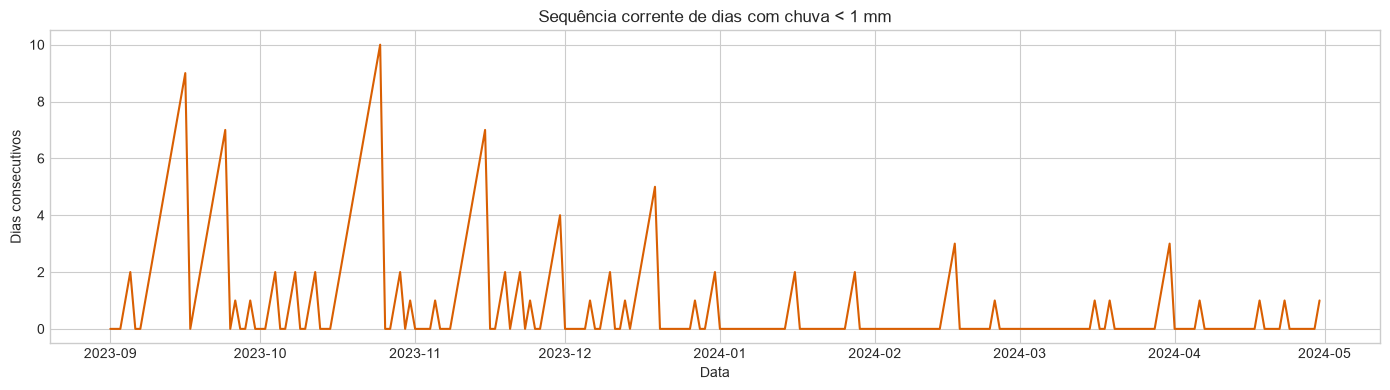

In [7]:
DRY_DAY_THRESHOLD_MM = 1.0
rain = weather["precipitation_mm_day"]
is_dry = rain.notna() & rain.lt(DRY_DAY_THRESHOLD_MM)
sequence_group = (~is_dry).cumsum()
weather["consecutive_dry_days"] = is_dry.groupby(sequence_group).cumsum().astype("int64")

max_dry_days = int(weather["consecutive_dry_days"].max())
longest_end = weather.loc[weather["consecutive_dry_days"].idxmax(), "date"]
longest_start = longest_end - pd.Timedelta(days=max_dry_days - 1)

print(f"Maior sequência sem chuva: {max_dry_days} dias")
print(f"Período da maior sequência: {longest_start.date()} a {longest_end.date()}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weather["date"], weather["consecutive_dry_days"], color="#d95f02")
ax.set(
    title=f"Sequência corrente de dias com chuva < {DRY_DAY_THRESHOLD_MM:g} mm",
    xlabel="Data",
    ylabel="Dias consecutivos",
)
fig.tight_layout()
plt.show()

## Leitura final

A análise conjunta permite verificar a integridade temporal antes de usar os dados em indicadores de estresse hídrico. A precipitação acumulada descreve a oferta de água ao longo do período, as sequências secas destacam intervalos potencialmente críticos e a amplitude térmica contextualiza a demanda atmosférica. O limiar de dia seco deve ser revisto conforme a definição agronômica adotada nas próximas etapas do projeto.